# Quadratic Model Fit to the data

Data: 

1. Developer engagement data
2. Repo growth data (innovation level)

In [1]:
# Pick your repo name here and then run the full notebook
# repo_name = 'jupyterlab/jupyter-ai'
# repo_name = 'jupyter-server/jupyter-scheduler'
repo_name = 'pandas-dev/pandas'
# repo_name = 'jupyterlab/jupyterlab'
# repo_name = 'langchain-ai/langchain'
# repo_name = 'langchain-ai/langchain-aws'

## Empirical Analysis 

Here we read in previously collected and curated data on a single open source project.

- Innovation $\Delta A(t)$ is $\Delta$ total\_changes (additions and subtractions of lines of code); and $A(t)$ is cumulative innovation.
- Resources (people), $L(t)$: contributors/developers to the open souce project.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_rows', None)

### Organize the data

In [3]:
package = repo_name.replace('/', '-')
df = pd.read_csv('../data/' + package + '-monthly.csv')
# df = pd.read_csv('pandas-dev-pandas-monthly.csv')
# df = pd.read_csv('vega-altair-monthly.csv')
df.drop("Unnamed: 0", axis=1, inplace=True)
print(df.shape)
df.head()

(199, 3)


,date,contributors,total_changes
0,2009-07-31 00:00:00+00:00,1,0
1,2009-08-31 00:00:00+00:00,1,21663
2,2009-09-30 00:00:00+00:00,1,2807
3,2009-10-31 00:00:00+00:00,1,975
4,2009-11-30 00:00:00+00:00,1,41097


In [4]:
df['date'] = [j.split()[0] for j in df['date']]
df['date'] = [pd.to_datetime(j) for j in df['date']]
df['cumInnovation'] = df['total_changes'].cumsum()
df.head()

,date,contributors,total_changes,cumInnovation
0,2009-07-31,1,0,0
1,2009-08-31,1,21663,21663
2,2009-09-30,1,2807,24470
3,2009-10-31,1,975,25445
4,2009-11-30,1,41097,66542


In [5]:
df.describe()

,date,contributors,total_changes,cumInnovation
count,199,199.000000,199.000000,1.990000e+02
mean,2017-10-30 07:43:06.934673408,40.361809,24667.361809,2.435339e+06
min,2009-07-31 00:00:00,1.000000,0.000000,0.000000e+00
25%,2013-09-15 00:00:00,26.000000,10814.000000,9.917110e+05
50%,2017-10-31 00:00:00,39.000000,17975.000000,2.236166e+06
75%,2021-12-15 12:00:00,56.000000,31061.000000,4.100474e+06
max,2026-01-31 00:00:00,153.000000,258031.000000,4.908805e+06
std,NaN,24.815476,26205.394123,1.648037e+06


### Plot and fit cumulative innovation $A(t)$ and Labor $L(t)$ to polynomials

- We fit a curve to both series and get fitted values.
- The main idea is to get a smooth plot over time that we can use to calibrate the parameters of the ODEs.
- As may be seen from the $R^2$ values, both series give a good polynomial fit.
- However, at low levels of time $t$, the fitted values are negative and we may later have to drop those. 

Quadratic equation: A(t) = 1.79e-02t² + 8.26e+02t + -2.71e+05
R² = 0.9879


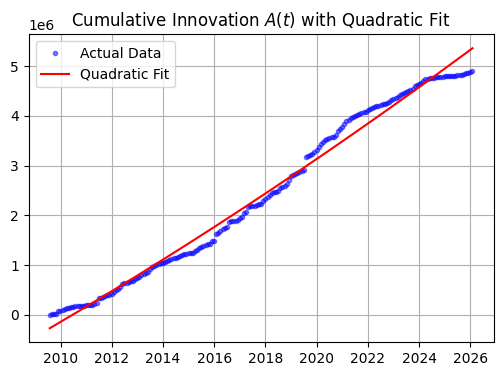

In [6]:
import numpy as np
from datetime import datetime

# Convert dates to numeric values (days since first date)
first_date = df['date'].min()
days = [(d - first_date).days for d in df['date']]

# Fit quadratic curve
coefficients = np.polyfit(days, df['cumInnovation'], deg=2)
a, b, c = coefficients

# Generate points for the fitted curve
days_range = np.array(days)
fitted_values = a * days_range**2 + b * days_range + c
cum_innovation_fitted_values = fitted_values.copy()

# Plot original data and fitted curve
plt.figure(figsize=(6, 4))
plt.plot(df['date'], df['cumInnovation'], 'b.', alpha=0.5, label='Actual Data')
plt.plot(df['date'], fitted_values, 'r-', label='Quadratic Fit')
plt.title("Cumulative Innovation $A(t)$ with Quadratic Fit")
plt.grid(True)
plt.legend()

# Print the equation of the fitted curve
print(f"Quadratic equation: A(t) = {a:.2e}t² + {b:.2e}t + {c:.2e}")

# Calculate R-squared
residuals = df['cumInnovation'] - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((df['cumInnovation'] - np.mean(df['cumInnovation']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² = {r_squared:.4f}")

plt.show()

Quadratic equation: L(t) = -4.39e-06t² + 3.61e-02t + -1.50e+01
R² = 0.6966


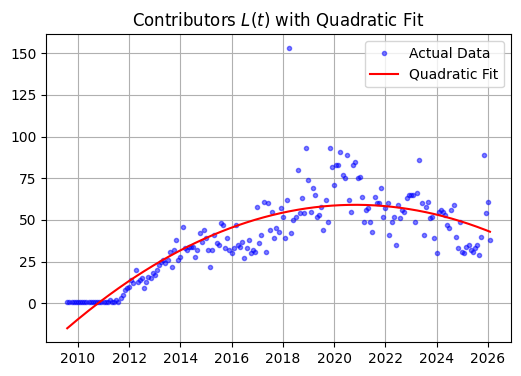

In [7]:
import numpy as np
from datetime import datetime

# Convert dates to numeric values (days since first date)
first_date = df['date'].min()
days = [(d - first_date).days for d in df['date']]

# Fit quadratic curve
coefficients = np.polyfit(days, df['contributors'], deg=2)
a, b, c = coefficients

# Generate points for the fitted curve
days_range = np.array(days)
fitted_values = a * days_range**2 + b * days_range + c
contributors_fitted_values = fitted_values.copy()

# Plot original data and fitted curve
plt.figure(figsize=(6, 4))
plt.plot(df['date'], df['contributors'], 'b.', alpha=0.5, label='Actual Data')
plt.plot(df['date'], fitted_values, 'r-', label='Quadratic Fit')
plt.title("Contributors $L(t)$ with Quadratic Fit")
plt.grid(True)
plt.legend()

# Print the equation of the fitted curve
print(f"Quadratic equation: L(t) = {a:.2e}t² + {b:.2e}t + {c:.2e}")

# Calculate R-squared
residuals = df['contributors'] - fitted_values
ss_res = np.sum(residuals**2)
ss_tot = np.sum((df['contributors'] - np.mean(df['contributors']))**2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² = {r_squared:.4f}")

plt.show()